In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np

import matplotlib
import matplotlib.animation as animation
import matplotlib.pyplot as plt
from IPython.display import HTML
import PIL.Image

from dm_control import mjcf
from dm_control import viewer

from swarmbots.unit import Unit
from swarmbots.rendering import display_video

In [2]:
RENDER_WIDTH = 640
RENDER_HEIGHT = 480

2 [0. 0.]


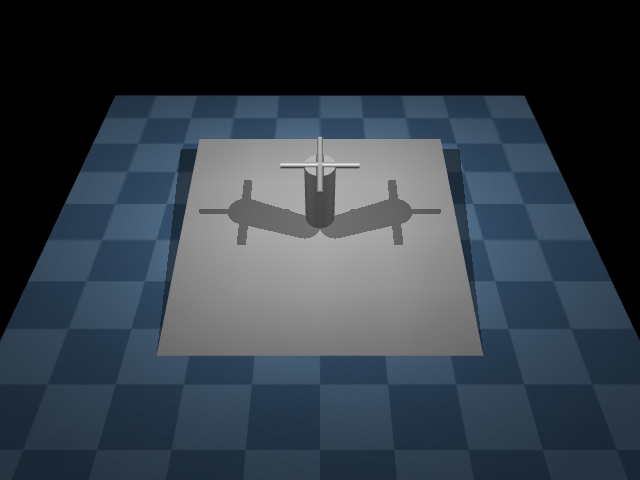

In [87]:
env = mjcf.RootElement()

getattr(env.visual, 'global').offwidth = RENDER_WIDTH
getattr(env.visual, 'global').offheight = RENDER_HEIGHT

chequered = env.asset.add('texture', type='2d', builtin='checker', width=300,
                            height=300, rgb1=[.2, .3, .4], rgb2=[.3, .4, .5])
grid = env.asset.add('material', name='grid', texture=chequered,
                       texrepeat=[5, 5], reflectance=.2)
env.worldbody.add('geom', type='plane', size=[2, 2, .1], material=grid)

for x in [-2, 2]:
  env.worldbody.add('light', pos=[x, -1, 3], dir=[-x, 1, -2])

unit1 = mjcf.RootElement()
unit1.compiler.angle = 'radian'

body = unit1.worldbody.add('body')
body.add('geom', type='box', size=[1, 0.1, 1])

appendage = body.add('body', pos=[0, -0.25, 0])
appendage.add('geom',  type='cylinder', fromto=[0, 0, 0, 0, -0.5, 0], size=[0.1])
appendage.add('geom', type='cylinder', fromto=[-0.25, -0.5, 0, 0.25, -0.5, 0], size=[0.02])
appendage.add('geom', type='cylinder', fromto=[0, -0.5, -0.25, 0, -0.5, 0.25], size=[0.02])
# appendage.add('joint', type='ball', range=[0, 0])#, range=[0, np.pi/2])
hinge1 = appendage.add('joint', type='hinge', axis=[0, 0, 1], range=[-np.pi/3, np.pi/3])
hinge2 = appendage.add('joint', type='hinge', axis=[1, 0, 0], range=[-np.pi/3, np.pi/3])
unit1.actuator.add('motor', joint=hinge1)
unit1.actuator.add('motor', joint=hinge2)

# spawn_site = env.worldbody.add('site', pos=[0, 0, 5], euler=[np.pi/2, 0, 0]) #, euler=[0, np.pi, 0])#, zaxis=[-np.sqrt(2/9), np.sqrt(2/3), -1/3])#euler=[0, np.pi, np.pi/2])
spawn_site = env.worldbody.add('site', pos=[0, 0, 0], euler=[-np.pi/2 + 0.1, 0, 0])
spawn_site.attach(unit1) #.add('freejoint')

cam = env.worldbody.add('camera', mode='targetbody', target=appendage, pos=[0, 1.5, 1])

physics = mjcf.Physics.from_mjcf_model(env)

print(physics.data.qvel.size, physics.data.qvel)
PIL.Image.fromarray(physics.render(width=RENDER_WIDTH, height=RENDER_HEIGHT, camera_id=-1))

In [88]:
duration = 5   # (Seconds)
framerate = 30  # (Hz)
video = []
 
last_switch = 0

# Simulate, saving video frames and torso locations.
physics.reset()
# physics.data.qvel[-1] = -200
# physics.data.qvel[-2] = -200

while physics.data.time < duration:
    physics.data.ctrl[1] = -physics.data.qpos[1] * np.exp(physics.data.qpos[1] * 6)
    # physics.data.ctrl[1] = -physics.data.qpos[1] * 50
    physics.step()

    # physics.data.ctrl[0] = np.sin(physics.data.time * 2) * 100
    # physics.data.ctrl[1] = np.sin(physics.data.time * np.pi) * 10
    # physics.data.ctrl[0] = np.exp(physics.data.time)
    # physics.data.ctrl[1] = np.exp(physics.data.time)

    # Save video frames.
    if len(video) < physics.data.time * framerate:
        
        pixels = physics.render(width=RENDER_WIDTH, height=RENDER_HEIGHT, camera_id=-1)
        video.append(pixels.copy())
    
        # for attribute_name in ['act', 'act_dot', 'actuator', 'actuator_force', 'actuator_length', 'actuator_moment', 'actuator_velocity']:
        #     print(f'{attribute_name}: {getattr(physics.data, attribute_name)}', end=' ')
        # print('\n')

    # if (physics.data.time - last_switch) > 0.5:
    #   last_switch = physics.data.time
    #   for i in range(4):
    #       physics.data.eq_active[i] = 1 - physics.data.eq_active[i]
    #   print(last_switch)
    
    # if physics.data.time > 3:
    #     physics.data.eq_active[0] = 0
    
    # if physics.data.time > 3.2:
    #     physics.data.eq_active[0] = 1
    
 

display_video(video, framerate)